# Zero-Noise Extrapolation (ZNE) — Gate-Folding Error Mitigation

In this notebook, we explore **Zero-Noise Extrapolation (ZNE)** to mitigate gate-level depolarizing errors on simulated quantum hardware. ZNE scales the physical noise of the circuit artificially using **Gate Folding** and extrapolates back to the zero-noise limit.

We evaluate ZNE fitting techniques (Linear, Quadratic, Exponential, and Richardson) on two quantum algorithms:
1. **Grover's Search Algorithm** (2-qubit)
2. **Quantum Fourier Transform (QFT)** (3-qubit)

All underlying gate-folding and simulation helpers are imported from our core `quantum_mitigation` library.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from quantum_mitigation import (
    grover_unitary, qft_unitary,
    noisy_simulator, ideal_simulator,
    run_zne_scan, zne_extrapolate,
    plot_zne_curves
)
%matplotlib inline


## 1. ZNE on Grover's Search Algorithm

We prepare a 2-qubit Grover's Search circuit targeting state $|11\rangle$. We execute ZNE with fold factors $\lambda \in \{1, 3, 5, 7, 9\}$ under a noisy simulator containing systematic two-qubit depolarizing gate noise.


In [3]:
sim_ideal = ideal_simulator()
sim_noisy = noisy_simulator()
unitary = grover_unitary()
fold_factors = np.array([1, 3, 5, 7, 9])

# Run ZNE scan (measured probabilities at each fold factor)
zne_probs = run_zne_scan(unitary, fold_factors, sim_noisy)
success_probs = zne_probs[:, 3]  # Target is |11> (index 3)

# Perform extrapolations
extrap_results = zne_extrapolate(fold_factors, success_probs)

print("Grover's Search ZNE Analysis (Ideal = 1.0000):\n")
print(f"  Unmitigated (fold=1): P(|11>) = {success_probs[0]:.4f} (error = {abs(1.0 - success_probs[0]):.4f})")
print("-" * 70)
for model, (val, r2) in extrap_results.items():
    print(f"  {model:<12} Fit -> Extrapolated = {val:.4f} | Error = {abs(1.0 - val):.4f} | R^2 = {r2:.6f}")


Grover's Search ZNE Analysis (Ideal = 1.0000):

  Unmitigated (fold=1): P(|11>) = 0.8865 (error = 0.1135)
----------------------------------------------------------------------
  Linear       Fit -> Extrapolated = 0.9044 | Error = 0.0956 | R^2 = 0.991552
  Quadratic    Fit -> Extrapolated = 0.9177 | Error = 0.0823 | R^2 = 0.997049
  Exponential  Fit -> Extrapolated = 0.9192 | Error = 0.0808 | R^2 = 0.997236
  Richardson   Fit -> Extrapolated = 0.9270 | Error = 0.0730 | R^2 = 0.998040


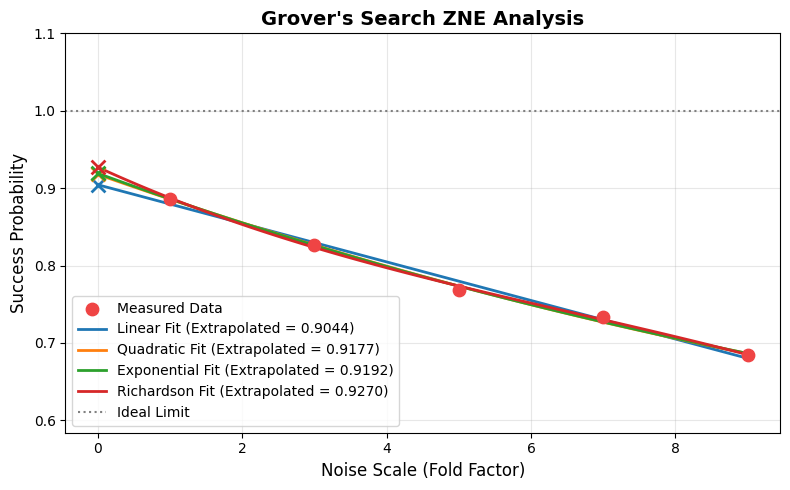

In [4]:
# Re-evaluate fit popt coefficients for visualization
from scipy.optimize import curve_fit
from quantum_mitigation.mitigation import FIT_MODELS

fit_curves = {}
for model, (func, p0) in FIT_MODELS.items():
    try:
        popt, _ = curve_fit(func, fold_factors, success_probs, p0=p0, maxfev=10000)
        val, r2 = extrap_results[model]
        if val is not None:
            fit_curves[model] = (val, popt, func)
    except Exception:
        pass

plot_zne_curves(fold_factors, success_probs, fit_curves, title="Grover's Search ZNE Analysis")
plt.show()


## 2. ZNE on the 3-Qubit Quantum Fourier Transform (QFT)

Next, we apply ZNE to a 3-qubit QFT circuit, evaluating the output state fidelity (Hellinger Fidelity) relative to the ideal noiseless distribution.


In [5]:
unitary_qft = qft_unitary(3)

# Run noiseless ideal simulation
ideal_probs = run_zne_scan(unitary_qft, [1], sim_ideal)
ideal_probs = ideal_probs[0]

# Run ZNE scan on noisy simulator
zne_probs_qft = run_zne_scan(unitary_qft, fold_factors, sim_noisy)

# Track Hellinger Fidelity with ideal distribution
from quantum_mitigation import hellinger_fidelity
fidelities = [hellinger_fidelity(probs, ideal_probs) for probs in zne_probs_qft]

# Perform extrapolations
extrap_results_qft = zne_extrapolate(fold_factors, fidelities)

print("3-Qubit QFT ZNE Analysis (Ideal Fidelity = 1.0000):\n")
print(f"  Unmitigated (fold=1): Fidelity = {fidelities[0]:.4f} (gap = {abs(1.0 - fidelities[0]):.4f})")
print("-" * 70)
for model, (val, r2) in extrap_results_qft.items():
    print(f"  {model:<12} Fit -> Extrapolated = {val:.4f} | Gap = {abs(1.0 - val):.4f} | R^2 = {r2:.6f}")


3-Qubit QFT ZNE Analysis (Ideal Fidelity = 1.0000):

  Unmitigated (fold=1): Fidelity = 0.9994 (gap = 0.0006)
----------------------------------------------------------------------
  Linear       Fit -> Extrapolated = 0.9996 | Gap = 0.0004 | R^2 = 0.496316
  Quadratic    Fit -> Extrapolated = 0.9995 | Gap = 0.0005 | R^2 = 0.582394
  Exponential  Fit -> Extrapolated = 1.1191 | Gap = 0.1191 | R^2 = 0.012506
  Richardson   Fit -> Extrapolated = 0.9991 | Gap = 0.0009 | R^2 = 0.988516


/home/ayush/Desktop/code/quantum-error-mitigation/quantum_mitigation/mitigation.py:54: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, fold_factors, measured_values, p0=p0, maxfev=10000)


/tmp/ipykernel_24573/196717322.py:4: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(func, fold_factors, fidelities, p0=p0, maxfev=10000)


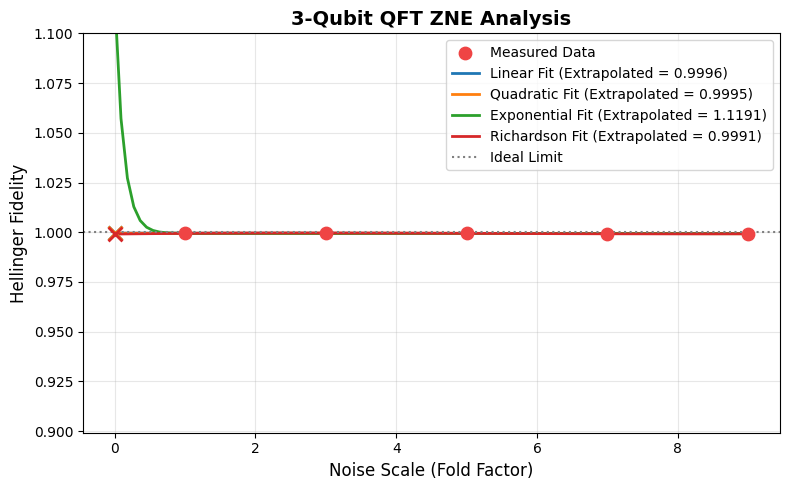

In [6]:
fit_curves_qft = {}
for model, (func, p0) in FIT_MODELS.items():
    try:
        popt, _ = curve_fit(func, fold_factors, fidelities, p0=p0, maxfev=10000)
        val, r2 = extrap_results_qft[model]
        if val is not None:
            fit_curves_qft[model] = (val, popt, func)
    except Exception:
        pass

plot_zne_curves(fold_factors, fidelities, fit_curves_qft, title="3-Qubit QFT ZNE Analysis", ylabel="Hellinger Fidelity")
plt.show()
